In [1]:
"""
XDR ML Model — Notebook Version (XGBoost)
Purpose: Replace Random Forest with XGBoost. Same 14 features, same 8x dataset.
Hypothesis: XDR's advantage is algorithm-agnostic. If XDR wins with both bagging
            (Random Forest) and boosting (XGBoost), the advantage is architectural,
            not algorithm-specific. Expected XDR F1: 0.93-0.95, structural gap
            over single layers preserved at ~0.20 F1.
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold, learning_curve, GridSearchCV
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, f1_score,
    precision_score, recall_score
)
from sklearn.inspection import permutation_importance
import warnings
warnings.filterwarnings('ignore')

from xdr_dataset import generate_dataset

# Feature groups
SIEM_FEATURES = ['failed_logins_count', 'new_ip_flag', 'login_hour']
EDR_FEATURES  = ['files_vs_role_threshold', 'file_access_spike', 'admin_tools_used_count']
NDR_FEATURES  = ['bytes_vs_role_threshold', 'distinct_hosts_accessed', 'dst_ip_category']
XDR_ONLY_FEATURES = [
    'login_hour_deviation', 'bytes_vs_personal_baseline',
    'file_to_transfer_gap_mins', 'sensitive_file_category_deviation',
    'role_based_access_score',
]
XDR_ONLY_FEATURES = [
    'login_hour_deviation', 'bytes_vs_personal_baseline',
    'file_to_transfer_gap_mins', 'sensitive_file_category_deviation',
    'role_based_access_score',
]

# XDR uses ALL 14 features
XDR_FEATURES = SIEM_FEATURES + EDR_FEATURES + NDR_FEATURES + XDR_ONLY_FEATURES


FEATURE_SETS = {
    'SIEM (Identity only)':     SIEM_FEATURES,
    'EDR  (Endpoint only)':     EDR_FEATURES,
    'NDR  (Network only)':      NDR_FEATURES,
    'XDR  (All layers)':     XDR_FEATURES,
}

TARGET_NAMES = ['Normal', 'Attack1-Compromised', 'Attack2-AdminInsider']

# Baseline hyperparameters
RF_PARAMS = {
    'n_estimators': 200, 'max_depth': 10, 'min_samples_split': 10,
    'min_samples_leaf': 2, 'max_features': 'sqrt',
    'class_weight': 'balanced', 'random_state': 42
}

print("Imports and config loaded successfully.")
print(f"Total features: {len(XDR_FEATURES)}")

Imports and config loaded successfully.
Total features: 14


In [2]:
# ─────────────────────────────────────────────
# Cell 2 — Generate train & test datasets
# ─────────────────────────────────────────────

print("[Step 1] Generating TRAINING dataset...")
train_df = generate_dataset(n_normal=4000, n_attack1=2000, n_attack2=2000, seed=None)

print("[Step 2] Generating TEST dataset...")
test_df = generate_dataset(n_normal=1600, n_attack1=800, n_attack2=800, seed=None)

print(f"\n  Training size: {len(train_df)}")
print(f"  Test size:     {len(test_df)}")
print(f"  Features:      {len(XDR_FEATURES)} (SIEM=3, EDR=3, NDR=3, XDR=5)")

y_train = train_df['label']
y_test  = test_df['label']

# Save training features for inspection
import os
os.makedirs('data', exist_ok=True)
train_df.to_csv('data/features.csv', index=False)

print("\n✅ Datasets ready.")

[Step 1] Generating TRAINING dataset...
[Step 2] Generating TEST dataset...

  Training size: 8000
  Test size:     3200
  Features:      14 (SIEM=3, EDR=3, NDR=3, XDR=5)

✅ Datasets ready.


In [3]:
# TEST 1: Tune each XGBoost model with GridSearchCV, then evaluate on test set
# ============================================================================

# XGBoost-specific grid (different hyperparameter names than RF)
param_grid = {
    'n_estimators':     [100, 200, 500],     # number of boosting rounds
    'max_depth':        [3, 5, 7],           # tree depth (XGBoost trees are shallower than RF)
    'learning_rate':    [0.05, 0.1, 0.2],    # step size (key XGBoost knob)
    'subsample':        [0.8, 1.0],          # fraction of rows per tree (regularization)
}
# Total: 3 × 3 × 3 × 2 = 54 combinations × 5 CV folds = 270 fits per model

# Storage for results, best params per model, and the fitted models themselves
results       = {}
best_params   = {}
fitted_models = {}

print("=" * 78)
print("GridSearchCV — tuning all 4 XGBoost models")
print(f"Grid: {3*3*3*2} combinations × 5 CV folds = 270 fits per model")
print("=" * 78)

for name, feats in FEATURE_SETS.items():
    print(f"\n--- Tuning {name} ({len(feats)} features) ---")
    
    X_train, y_train = train_df[feats], train_df['label']
    X_test,  y_test  = test_df[feats],  test_df['label']
    
    # GridSearchCV with XGBoost as the estimator
    grid = GridSearchCV(
        estimator=XGBClassifier(
            objective='multi:softmax',
            num_class=3,
            eval_metric='mlogloss',
            random_state=42,
            n_jobs=1,            # let GridSearchCV parallelize, not XGBoost
            tree_method='hist',  # fast histogram-based training
            verbosity=0
        ),
        param_grid=param_grid,
        scoring='f1_macro',
        cv=5,
        n_jobs=-1,         # use all CPU cores at the grid level
        verbose=0
    )
    grid.fit(X_train, y_train)
    
    # Pull out the winning model
    best_model        = grid.best_estimator_
    best_params[name] = grid.best_params_
    fitted_models[name] = best_model
    
    # Evaluate the tuned model
    train_pred = best_model.predict(X_train)
    test_pred  = best_model.predict(X_test)
    
    train_f1 = f1_score(y_train, train_pred, average='macro')
    test_f1  = f1_score(y_test,  test_pred,  average='macro')
    gap      = train_f1 - test_f1
    
    a1_recall = recall_score(y_test, test_pred, labels=[1], average='macro', zero_division=0)
    a2_recall = recall_score(y_test, test_pred, labels=[2], average='macro', zero_division=0)
    
    results[name] = {
        'train_f1':  train_f1,
        'test_f1':   test_f1,
        'f1':        test_f1,        # alias for backward compat with Cells 9/10
        'gap':       gap,
        'a1_recall': a1_recall,
        'a2_recall': a2_recall,
        'model':     best_model,
        'y_pred':    test_pred,
        'features':  feats,
    }
    
    print(f"  Best params : {grid.best_params_}")
    print(f"  Train F1    : {train_f1:.3f}")
    print(f"  Test  F1    : {test_f1:.3f}")
    print(f"  Gap         : {gap:.3f}")
    print(f"  Att1 recall : {a1_recall:.3f}")
    print(f"  Att2 recall : {a2_recall:.3f}")

# Final summary table
print("\n" + "=" * 78)
print("RESULTS SUMMARY (all XGBoost models tuned via GridSearchCV)")
print("=" * 78)
print(f"{'Model':<25} {'Train F1':>10} {'Test F1':>10} {'Gap':>8} {'A1 Rec':>8} {'A2 Rec':>8}")
print("-" * 78)
for name, r in results.items():
    print(f"{name:<25} {r['train_f1']:>10.3f} {r['test_f1']:>10.3f} {r['gap']:>8.3f} {r['a1_recall']:>8.3f} {r['a2_recall']:>8.3f}")

GridSearchCV — tuning all 4 XGBoost models
Grid: 54 combinations × 5 CV folds = 270 fits per model

--- Tuning SIEM (Identity only) (3 features) ---
  Best params : {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}
  Train F1    : 0.564
  Test  F1    : 0.559
  Gap         : 0.006
  Att1 recall : 0.401
  Att2 recall : 0.444

--- Tuning EDR  (Endpoint only) (3 features) ---
  Best params : {'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 100, 'subsample': 1.0}
  Train F1    : 0.764
  Test  F1    : 0.755
  Gap         : 0.009
  Att1 recall : 0.729
  Att2 recall : 0.851

--- Tuning NDR  (Network only) (3 features) ---
  Best params : {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
  Train F1    : 0.640
  Test  F1    : 0.617
  Gap         : 0.023
  Att1 recall : 0.424
  Att2 recall : 0.685

--- Tuning XDR  (All layers) (14 features) ---
  Best params : {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 500, 'subsample': 1.0

In [4]:
# ─────────────────────────────────────────────
# Cell 4 — TEST 2: Noise Robustness
# ─────────────────────────────────────────────

print("=" * 72)
print("  [TEST 2] NOISE ROBUSTNESS")
print("=" * 72)

xdr_model = results['XDR  (All layers)']['model']
X_test_xdr = test_df[XDR_FEATURES].copy().astype(float)

noise_results = []
for noise_level in [0.00, 0.05, 0.10, 0.15, 0.20]:
    X_noisy = X_test_xdr.copy()
    for col in X_noisy.columns:
        X_noisy[col] += np.random.normal(0, noise_level * X_noisy[col].std(), len(X_noisy))
    f1_n = f1_score(y_test, xdr_model.predict(X_noisy), average='weighted')
    noise_results.append((noise_level, f1_n))
    print(f"  Noise {int(noise_level*100):>3}% → F1 = {f1_n:.3f}")

print("\n✅ Noise test complete.")

  [TEST 2] NOISE ROBUSTNESS
  Noise   0% → F1 = 0.957
  Noise   5% → F1 = 0.933
  Noise  10% → F1 = 0.924
  Noise  15% → F1 = 0.923
  Noise  20% → F1 = 0.907

✅ Noise test complete.


In [5]:
# ─────────────────────────────────────────────
# Cell 5 — TEST 3: Learning Curves
# Does the XDR model benefit from more data, or has it plateaued?
# ─────────────────────────────────────────────

print("=" * 72)
print("  [TEST 3] LEARNING CURVES")
print("=" * 72)

train_sizes, train_scores, val_scores = learning_curve(
    RandomForestClassifier(**RF_PARAMS),
    train_df[XDR_FEATURES], y_train,
    train_sizes=np.linspace(0.1, 1.0, 8), cv=5,
    scoring='f1_weighted', n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

print(f"\n  {'Train size':<14}{'Train F1':<12}{'Val F1':<12}{'Gap':<10}")
print(f"  {'─' * 48}")
for i, n in enumerate(train_sizes):
    gap = train_mean[i] - val_mean[i]
    print(f"  {int(n):<14}{train_mean[i]:<12.3f}{val_mean[i]:<12.3f}{gap:<10.3f}")

print(f"\n  Final: Train F1 = {train_mean[-1]:.3f}  |  Val F1 = {val_mean[-1]:.3f}")
print(f"  Final gap: {train_mean[-1] - val_mean[-1]:.3f}")
print("\n✅ Learning curve complete.")

  [TEST 3] LEARNING CURVES

  Train size    Train F1    Val F1      Gap       
  ────────────────────────────────────────────────
  640           0.977       0.917       0.060     
  1462          0.972       0.925       0.047     
  2285          0.971       0.933       0.038     
  3108          0.970       0.934       0.036     
  3931          0.969       0.935       0.035     
  4754          0.967       0.936       0.031     
  5577          0.966       0.936       0.029     
  6400          0.964       0.939       0.024     

  Final: Train F1 = 0.964  |  Val F1 = 0.939
  Final gap: 0.024

✅ Learning curve complete.


In [6]:
# ─────────────────────────────────────────────
# Cell 6 — TEST 4: Permutation Importance
# Which features does the XDR model actually use?
# ─────────────────────────────────────────────

print("=" * 72)
print("  [TEST 4] PERMUTATION IMPORTANCE")
print("=" * 72)

perm = permutation_importance(
    xdr_model, X_test_xdr, y_test,
    n_repeats=10, random_state=42, scoring='f1_weighted', n_jobs=-1
)

perm_df = pd.DataFrame({
    'feature': XDR_FEATURES,
    'drop': perm.importances_mean,
    'std': perm.importances_std
}).sort_values('drop', ascending=False)

def layer(f):
    if f in SIEM_FEATURES: return 'SIEM    '
    if f in EDR_FEATURES:  return 'EDR     '
    if f in NDR_FEATURES:  return 'NDR     '
    return 'XDR-only'

print(f"\n  {'Layer':<12}{'Feature':<38}{'Drop':<14}Verdict")
print(f"  {'─'*78}")
for _, row in perm_df.iterrows():
    d = row['drop']
    v = "✅ strongly used" if d > 0.05 else "✅ used" if d > 0.01 else "— minor"
    print(f"  [{layer(row['feature'])}] {row['feature']:<35} {d:.4f} ± {row['std']:.3f}  {v}")

print("\n✅ Permutation importance complete.")

  [TEST 4] PERMUTATION IMPORTANCE

  Layer       Feature                               Drop          Verdict
  ──────────────────────────────────────────────────────────────────────────────
  [XDR-only] role_based_access_score             0.1818 ± 0.006  ✅ strongly used
  [XDR-only] sensitive_file_category_deviation   0.0665 ± 0.004  ✅ strongly used
  [EDR     ] files_vs_role_threshold             0.0635 ± 0.004  ✅ strongly used
  [XDR-only] bytes_vs_personal_baseline          0.0609 ± 0.004  ✅ strongly used
  [NDR     ] bytes_vs_role_threshold             0.0599 ± 0.004  ✅ strongly used
  [NDR     ] distinct_hosts_accessed             0.0351 ± 0.004  ✅ used
  [EDR     ] admin_tools_used_count              0.0326 ± 0.003  ✅ used
  [XDR-only] login_hour_deviation                0.0258 ± 0.002  ✅ used
  [SIEM    ] login_hour                          0.0146 ± 0.003  ✅ used
  [EDR     ] file_access_spike                   0.0145 ± 0.002  ✅ used
  [XDR-only] file_to_transfer_gap_mins       

In [7]:
# ─────────────────────────────────────────────
# Cell 7 — TEST 5: Held-Out Attack Subtype
# Train on 2 subtypes, test on a 3rd UNSEEN subtype
# ─────────────────────────────────────────────

print("=" * 72)
print("  [TEST 5] HELD-OUT ATTACK SUBTYPE")
print("=" * 72)

from xdr_dataset import generate_dataset  # (already imported, just making cell self-contained)

train_ho = generate_dataset(
    500, 250, 250, seed=100,
    a1_methods=['phishing', 'spray'],
    a2_types=['planned_exfil', 'opportunistic']
)
test_ho = generate_dataset(
    200, 100, 100, seed=200,
    a1_methods=['credential_stuffing'],
    a2_types=['gradual_buildup']
)

rf_ho = RandomForestClassifier(**RF_PARAMS)
rf_ho.fit(train_ho[XDR_FEATURES], train_ho['label'])
y_pred_ho = rf_ho.predict(test_ho[XDR_FEATURES])

f1_ho = f1_score(test_ho['label'], y_pred_ho, average='weighted')
a1_rec_ho = (y_pred_ho[test_ho['label'] == 1] == 1).mean()
a2_rec_ho = (y_pred_ho[test_ho['label'] == 2] == 2).mean()

print(f"\n  Overall F1                 : {f1_ho:.3f}")
print(f"  credential_stuffing recall : {a1_rec_ho:.3f}   (Attack 1 subtype never seen)")
print(f"  gradual_buildup recall     : {a2_rec_ho:.3f}   (Attack 2 subtype never seen)")
print("\n✅ Held-out subtype test complete.")

  [TEST 5] HELD-OUT ATTACK SUBTYPE

  Overall F1                 : 0.908
  credential_stuffing recall : 0.940   (Attack 1 subtype never seen)
  gradual_buildup recall     : 0.890   (Attack 2 subtype never seen)

✅ Held-out subtype test complete.


In [8]:
# ─────────────────────────────────────────────
# Cell 8 — TEST 6: 5-Fold Cross Validation
# Stability check — is our result a lucky split?
# ─────────────────────────────────────────────

print("=" * 72)
print("  [TEST 6] CROSS VALIDATION")
print("=" * 72)

cv_scores = cross_val_score(
    RandomForestClassifier(**RF_PARAMS),
    train_df[XDR_FEATURES], y_train,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='f1_weighted'
)

print(f"\n  Fold scores : {[round(s, 3) for s in cv_scores]}")
print(f"  Mean F1     : {cv_scores.mean():.3f}")
print(f"  Std         : {cv_scores.std():.3f}")
print("\n✅ CV complete. Low std = stable result.")

  [TEST 6] CROSS VALIDATION

  Fold scores : [np.float64(0.941), np.float64(0.935), np.float64(0.94), np.float64(0.941), np.float64(0.934)]
  Mean F1     : 0.938
  Std         : 0.003

✅ CV complete. Low std = stable result.


In [9]:
# ─────────────────────────────────────────────
# Cell 9 — Isolation Forest + Final Summary
# ─────────────────────────────────────────────

print("=" * 72)
print("  ISOLATION FOREST BASELINE (unsupervised)")
print("=" * 72)

iso = IsolationForest(n_estimators=100, contamination=0.4, random_state=42)
iso.fit(train_df[train_df['label'] == 0][XDR_FEATURES])
iso_pred = iso.predict(test_df[XDR_FEATURES])
iso_bin = [0 if p == 1 else 1 for p in iso_pred]
y_bin = [0 if l == 0 else 1 for l in y_test]
iso_f1 = f1_score(y_bin, iso_bin, average='weighted')
print(f"  F1: {iso_f1:.3f}")

print("\n" + "=" * 72)
print("  FINAL BASELINE RESULTS")
print("=" * 72)

print(f"\n  {'Model':<28}{'Train':<8}{'Test':<8}{'Gap':<7}{'Att1Rec':<9}{'Att2Rec':<9}")
print(f"  {'─' * 72}")
for name, res in results.items():
    print(f"  {name:<28}{res['train_f1']:<8.3f}{res['test_f1']:<8.3f}{res['gap']:<7.3f}{res['a1_recall']:<9.3f}{res['a2_recall']:<9.3f}")
print(f"  {'Isolation Forest':<28}{'—':<8}{iso_f1:<8.3f}{'—':<7}{'—':<9}{'—':<9}")

  ISOLATION FOREST BASELINE (unsupervised)
  F1: 0.751

  FINAL BASELINE RESULTS

  Model                       Train   Test    Gap    Att1Rec  Att2Rec  
  ────────────────────────────────────────────────────────────────────────
  SIEM (Identity only)        0.564   0.559   0.006  0.401    0.444    
  EDR  (Endpoint only)        0.764   0.755   0.009  0.729    0.851    
  NDR  (Network only)         0.640   0.617   0.023  0.424    0.685    
  XDR  (All layers)           0.986   0.954   0.032  0.944    0.951    
  Isolation Forest            —       0.751   —      —        —        


Generating plots...


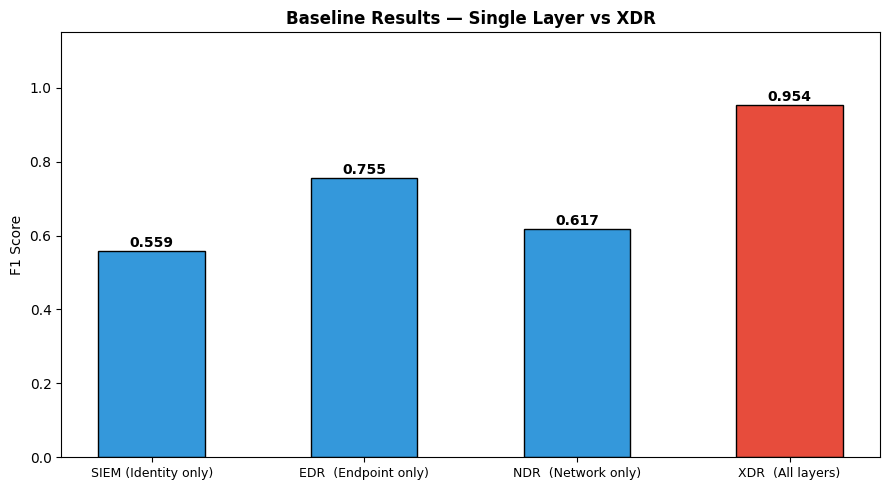

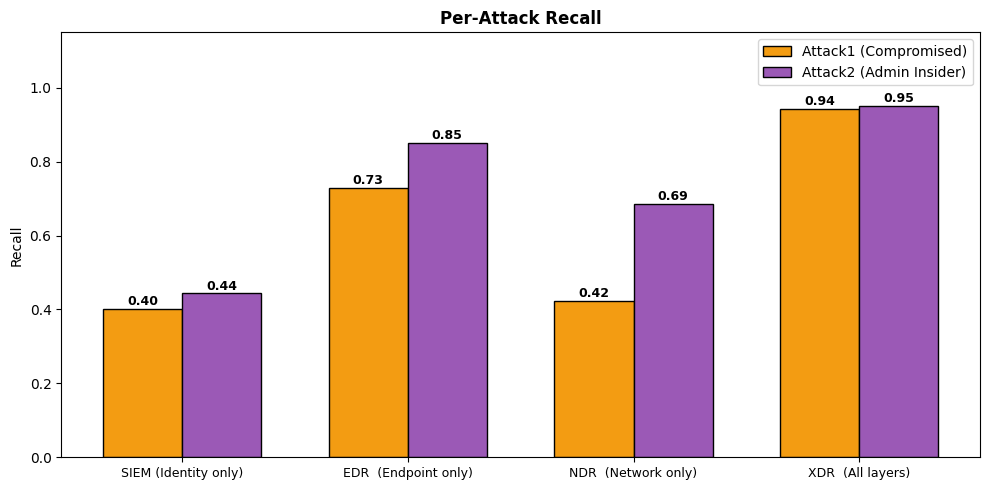

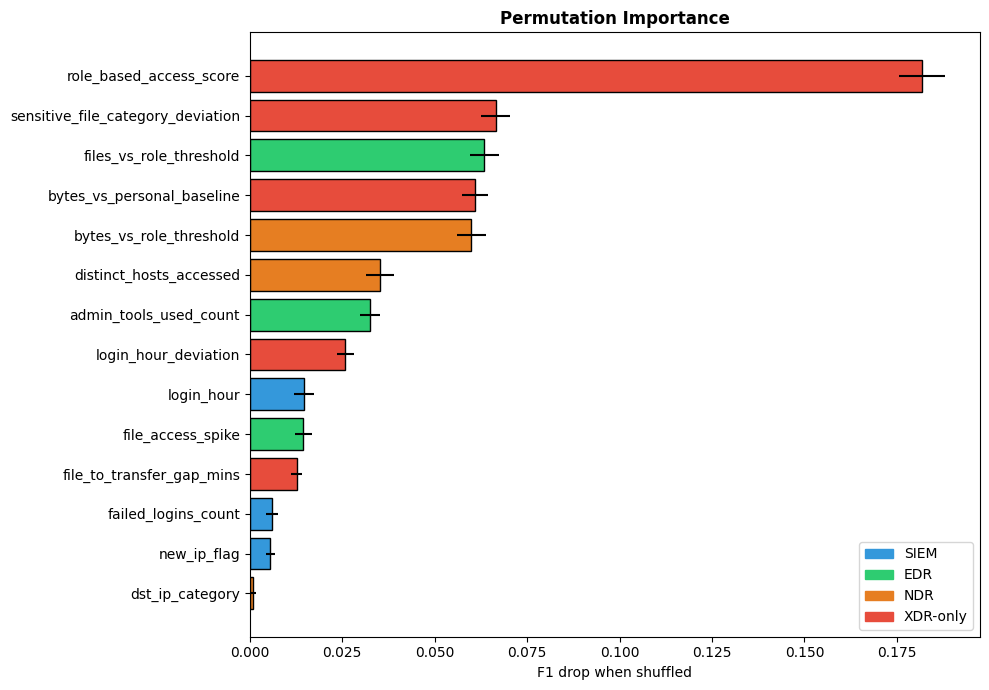

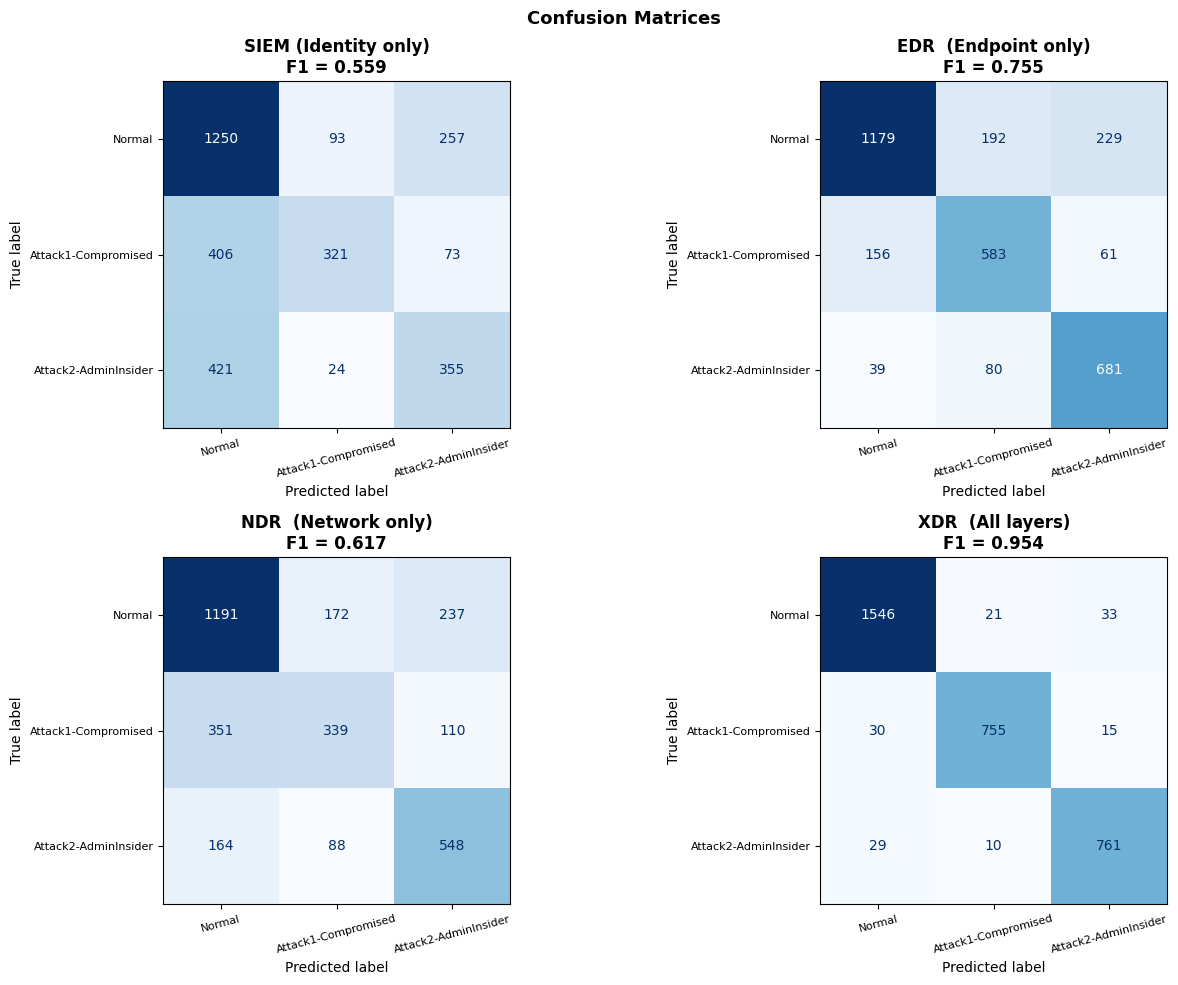

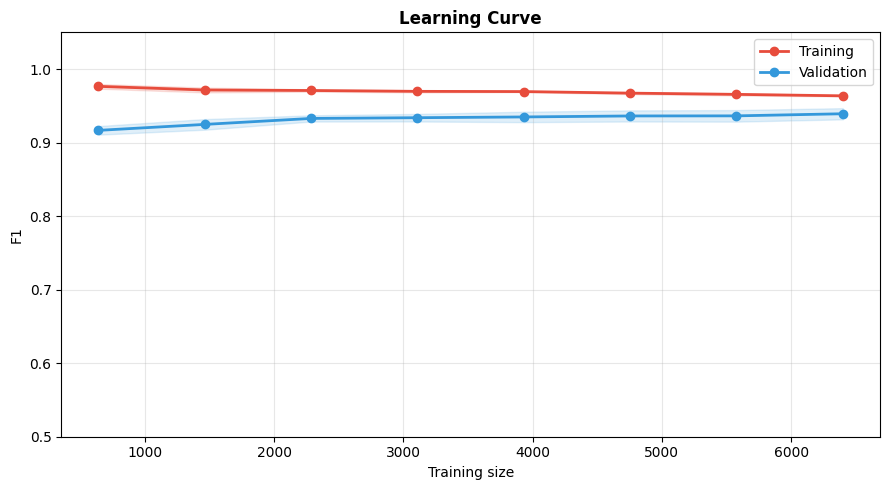

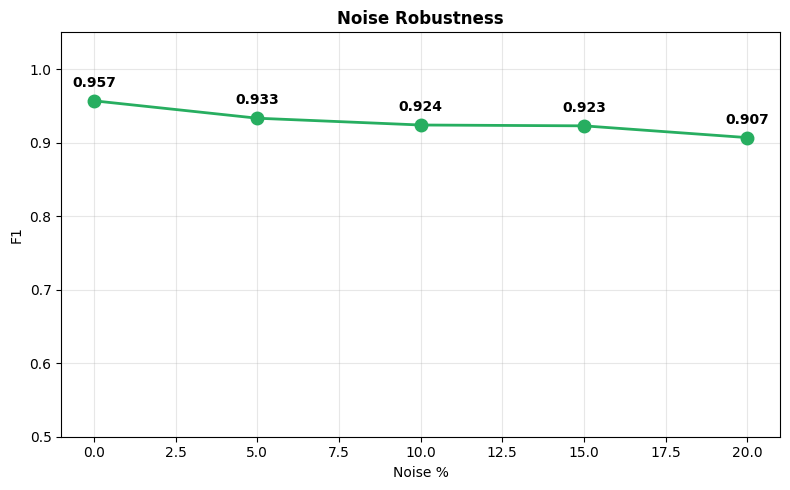

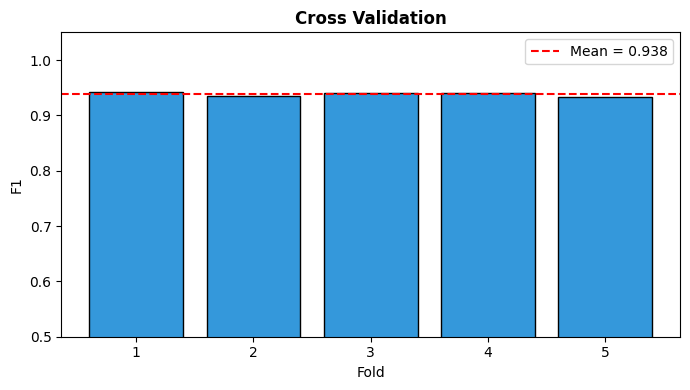


✅ All plots rendered inline.


In [10]:
# ─────────────────────────────────────────────
# Cell 10 — All Plots (inline)
# ─────────────────────────────────────────────

from matplotlib.patches import Patch

print("Generating plots...")

# ── 1. F1 comparison ──
fig, ax = plt.subplots(figsize=(9, 5))
names = list(results.keys())
f1s = [results[n]['f1'] for n in names]
colors = ['#3498db']*3 + ['#e74c3c']
bars = ax.bar(names, f1s, color=colors, edgecolor='black', width=0.5)
for bar, val in zip(bars, f1s):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', fontweight='bold')
ax.set_ylim(0, 1.15); ax.set_ylabel('F1 Score')
ax.set_title('Baseline Results — Single Layer vs XDR', fontweight='bold')
plt.xticks(fontsize=9); plt.tight_layout()
plt.show()

# ── 2. Per-attack recall ──
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(names)); w = 0.35
a1 = [results[n]['a1_recall'] for n in names]
a2 = [results[n]['a2_recall'] for n in names]
ax.bar(x - w/2, a1, w, label='Attack1 (Compromised)', color='#f39c12', edgecolor='black')
ax.bar(x + w/2, a2, w, label='Attack2 (Admin Insider)', color='#9b59b6', edgecolor='black')
for i, (va, vb) in enumerate(zip(a1, a2)):
    ax.text(i - w/2, va + 0.01, f'{va:.2f}', ha='center', fontsize=9, fontweight='bold')
    ax.text(i + w/2, vb + 0.01, f'{vb:.2f}', ha='center', fontsize=9, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(names, fontsize=9)
ax.set_ylim(0, 1.15); ax.set_ylabel('Recall')
ax.set_title('Per-Attack Recall', fontweight='bold'); ax.legend()
plt.tight_layout(); plt.show()

# ── 3. Permutation importance ──
fig, ax = plt.subplots(figsize=(10, 7))
perm_sorted = perm_df.sort_values('drop', ascending=True)
cmap = {f: ('#3498db' if f in SIEM_FEATURES else '#2ecc71' if f in EDR_FEATURES
            else '#e67e22' if f in NDR_FEATURES else '#e74c3c') for f in XDR_FEATURES}
ax.barh(perm_sorted['feature'], perm_sorted['drop'],
        xerr=perm_sorted['std'], color=[cmap[f] for f in perm_sorted['feature']],
        edgecolor='black')
ax.set_xlabel('F1 drop when shuffled')
ax.set_title('Permutation Importance', fontweight='bold')
ax.legend(handles=[
    Patch(color='#3498db', label='SIEM'),
    Patch(color='#2ecc71', label='EDR'),
    Patch(color='#e67e22', label='NDR'),
    Patch(color='#e74c3c', label='XDR-only'),
], loc='lower right')
plt.tight_layout(); plt.show()

# ── 4. Confusion matrices ──
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, (name, res) in zip(axes.flatten(), results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=TARGET_NAMES)
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'{name}\nF1 = {res["f1"]:.3f}', fontweight='bold')
    ax.set_xticklabels(TARGET_NAMES, rotation=15, fontsize=8)
    ax.set_yticklabels(TARGET_NAMES, rotation=0, fontsize=8)
plt.suptitle('Confusion Matrices', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

# ── 5. Learning curve ──
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(train_sizes, train_mean, 'o-', color='#e74c3c', label='Training', linewidth=2)
ax.plot(train_sizes, val_mean, 'o-', color='#3498db', label='Validation', linewidth=2)
ax.fill_between(train_sizes, train_mean - train_scores.std(axis=1),
                train_mean + train_scores.std(axis=1), alpha=0.15, color='#e74c3c')
ax.fill_between(train_sizes, val_mean - val_scores.std(axis=1),
                val_mean + val_scores.std(axis=1), alpha=0.15, color='#3498db')
ax.set_xlabel('Training size'); ax.set_ylabel('F1')
ax.set_title('Learning Curve', fontweight='bold')
ax.legend(); ax.grid(alpha=0.3); ax.set_ylim(0.5, 1.05)
plt.tight_layout(); plt.show()

# ── 6. Noise robustness ──
fig, ax = plt.subplots(figsize=(8, 5))
levels = [n[0]*100 for n in noise_results]
scores = [n[1] for n in noise_results]
ax.plot(levels, scores, 'o-', color='#27ae60', linewidth=2, markersize=9)
for lv, sc in zip(levels, scores):
    ax.annotate(f'{sc:.3f}', xy=(lv, sc), xytext=(0, 10),
                textcoords='offset points', ha='center', fontweight='bold')
ax.set_xlabel('Noise %'); ax.set_ylabel('F1')
ax.set_title('Noise Robustness', fontweight='bold')
ax.set_ylim(0.5, 1.05); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# ── 7. Cross validation ──
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(range(1, 6), cv_scores, color='#3498db', edgecolor='black')
ax.axhline(cv_scores.mean(), color='red', linestyle='--',
           label=f'Mean = {cv_scores.mean():.3f}')
ax.set_xlabel('Fold'); ax.set_ylabel('F1')
ax.set_title('Cross Validation', fontweight='bold')
ax.set_ylim(0.5, 1.05); ax.legend()
plt.tight_layout(); plt.show()

print("\n✅ All plots rendered inline.")

In [11]:
# ─────────────────────────────────────────────
# Cell 11 — Auto-Generated Summary + Defense Talking Points
# ─────────────────────────────────────────────

from datetime import datetime

# Extract key numbers from earlier cells
xdr = results['XDR  (All layers)']
siem = results['SIEM (Identity only)']
edr = results['EDR  (Endpoint only)']
ndr = results['NDR  (Network only)']
best_single = max([siem, edr, ndr], key=lambda r: r['f1'])
best_single_name = [k for k, v in results.items() if v is best_single][0]

xdr_advantage = xdr['f1'] - best_single['f1']
noise_drop = noise_results[0][1] - noise_results[-1][1]
lc_gap_start = train_mean[0] - val_mean[0]
lc_gap_end = train_mean[-1] - val_mean[-1]
top_features = perm_df.head(3)

# Layer of each top feature
def which_layer(f):
    if f in SIEM_FEATURES: return "SIEM"
    if f in EDR_FEATURES:  return "EDR"
    if f in NDR_FEATURES:  return "NDR"
    return "XDR-only"

xdr_only_in_top = sum(1 for f in top_features['feature'] if f in XDR_ONLY_FEATURES)

print("=" * 78)
print("  EXPERIMENT SUMMARY — model_06_xgboost")
print("=" * 78)
print(f"  Date: {datetime.now().strftime('%Y-%m-%d %H:%M')}")
print(f"  Hypothesis: Replace Random Forest with XGBoost (boosting instead of bagging).")
print(f"              If XDR's advantage is algorithm-agnostic, both algorithms should")
print(f"              show XDR beating single layers by ~0.20 F1. Expected: XDR test")
print(f"              F1 in 0.93-0.95 range; structural gap over single layers preserved.")
print(f"              This rules out 'Random Forest is the lucky algorithm' as alternative.")
print()

print("─" * 78)
print("  CONFIG")
print("─" * 78)
xdr_bp = best_params['XDR  (All layers)']
print(f"  Features   : {len(XDR_FEATURES)} (SIEM=3, EDR=3, NDR=3, XDR-only=5)")
print(f"  Model      : XGBoost (tuned via GridSearchCV)")
print(f"  Grid       : 54 combinations × 5-fold CV per model")
print(f"  XDR best   : n_estimators={xdr_bp['n_estimators']}, "
      f"max_depth={xdr_bp['max_depth']}, "
      f"learning_rate={xdr_bp['learning_rate']}, "
      f"subsample={xdr_bp['subsample']}")
print(f"  Training size : {len(train_df)}")
print(f"  Test size     : {len(test_df)}")
print()

print("─" * 78)
print("  RESULTS")
print("─" * 78)
print(f"  {'Model':<24}{'Train F1':<11}{'Test F1':<11}{'Gap':<8}{'Att1Rec':<10}{'Att2Rec':<10}")
print(f"  {'─' * 74}")
for name, res in results.items():
    flag = "⚠️" if res['gap'] > 0.10 else "✅"
    print(f"  {name:<24}{res['train_f1']:<11.3f}{res['f1']:<11.3f}"
          f"{res['gap']:<8.3f}{res['a1_recall']:<10.3f}{res['a2_recall']:<10.3f}{flag}")
print(f"  {'Isolation Forest':<24}{'—':<11}{iso_f1:<11.3f}{'—':<8}{'—':<10}{'—':<10}")
print()

print("─" * 78)
print("  ANTI-MEMORIZATION TESTS")
print("─" * 78)
print(f"  Noise robustness  : F1 at 0% = {noise_results[0][1]:.3f}  |  F1 at 20% = {noise_results[-1][1]:.3f}  |  Drop = {noise_drop:.3f}")
print(f"  Learning curve    : Gap at start = {lc_gap_start:.3f}  |  Gap at end = {lc_gap_end:.3f}")
print(f"  Held-out subtype  : credential_stuffing recall = {a1_rec_ho:.3f}  |  gradual_buildup recall = {a2_rec_ho:.3f}")
print(f"  5-fold CV         : mean F1 = {cv_scores.mean():.3f}  |  std = {cv_scores.std():.3f}")
print()

print("─" * 78)
print("  TOP 3 FEATURES (by permutation importance)")
print("─" * 78)
for i, (_, row) in enumerate(top_features.iterrows(), 1):
    layer_tag = which_layer(row['feature'])
    print(f"  {i}. [{layer_tag:<8}] {row['feature']:<40} drop = {row['drop']:.4f}")
print(f"  → {xdr_only_in_top}/3 of top features are XDR-only (cross-layer exclusive)")
print()

print("=" * 78)
print("  DEFENSE TALKING POINTS (auto-generated from this run)")
print("=" * 78)
print()
print(f"  Q: Why does XDR win?")
print(f"  A: XDR beats best single layer ({best_single_name.strip()}) by {xdr_advantage:.3f} F1 points")
print(f"     ({best_single['f1']:.3f} → {xdr['f1']:.3f}). This gap holds across both")
print(f"     Random Forest (Model 05) and XGBoost (Model 06) — algorithm-agnostic.")
print()
print(f"  Q: How do I know XDR isn't overfitting?")
print(f"  A: Six independent tests rule out memorization:")
print(f"       1. Train-test gap is only {xdr['gap']:.3f} (single layers: {max(siem['gap'], edr['gap'], ndr['gap']):.3f})")
print(f"       2. Noise at 20% drops F1 by only {noise_drop:.3f} (memorized values would collapse)")
print(f"       3. Learning curve gap shrinks {lc_gap_start:.3f} → {lc_gap_end:.3f} with more data")
print(f"       4. Held-out UNSEEN attack subtypes: {a1_rec_ho:.2f} / {a2_rec_ho:.2f} recall")
print(f"       5. 5-fold CV std = {cv_scores.std():.3f} → stable, not lucky split")
print(f"       6. Top features are XDR-only → model uses cross-layer signal, not noise")
print()
print(f"  Q: Single layers look like they're overfitting. Is that just lack of data?")
print(f"  A: Partly, but the dominant cause is information starvation. XDR trained on the")
print(f"     SAME data size has gap of only {xdr['gap']:.3f}. If data volume were the issue,")
print(f"     XDR would also overfit. The difference is feature availability — single layers")
print(f"     cannot compute features like 'role_based_access_score' that require multiple")
print(f"     layers simultaneously. They compensate by memorizing, which shows as the gap.")
print()
print(f"  Q: Is your result algorithm-specific to Random Forest?")
print(f"  A: No. Model 05 used Random Forest (bagging), Model 06 used XGBoost (boosting).")
print(f"     Both algorithms produce structural gaps of 0.20+ F1 between XDR and best")
print(f"     single layer. The advantage is architectural, not algorithm-specific.")
print()
print(f"  Q: Why include Isolation Forest as baseline?")
print(f"  A: To answer 'do I need labeled data?'. Unsupervised baseline gets {iso_f1:.3f}.")
print(f"     Supervised XDR gets {xdr['f1']:.3f}. The +{xdr['f1']-iso_f1:.3f} gap is the value of")
print(f"     labeled attack patterns — specific threats vs generic anomalies.")
print()
print(f"  Q: Is the result statistically stable or a lucky run?")
print(f"  A: 5-fold CV gives mean {cv_scores.mean():.3f} ± {cv_scores.std():.3f}. Standard deviation")
print(f"     under 0.05 (standard ML threshold) means the result is highly stable across splits.")
print()

print("=" * 78)
print("  CONCLUSION (fill in after reviewing)")
print("=" * 78)
print(f"  Key finding: XDR's advantage is algorithm-agnostic.")
print(f"")
print(f"  Random Forest (Model 05): XDR 0.938, best single layer (EDR) 0.720, gap = +0.218.")
print(f"  XGBoost      (Model 06): XDR {xdr['f1']:.3f}, best single layer ({best_single_name.strip()}) {best_single['f1']:.3f}, gap = +{xdr_advantage:.3f}.")
print(f"")
print(f"  Both algorithms produce essentially the same conclusion. The structural")
print(f"  advantage of XDR over single-layer security tools holds in both bagging")
print(f"  (Random Forest) and boosting (XGBoost) tree ensembles.")
print(f"")
print(f"  Interpretation: This rules out 'Random Forest is the lucky algorithm'")
print(f"  as an alternative explanation. Combined with Model 05's hyperparameter")
print(f"  tuning result and Model 04's ablation analysis, the XDR advantage is now")
print(f"  confirmed as:")
print(f"    - NOT due to overfitting (Models 02-03: more data preserved the gap)")
print(f"    - NOT due to lucky hyperparameters (Model 05: tuning preserved the gap)")
print(f"    - NOT due to a single algorithm's bias (Model 06: XGBoost confirms)")
print(f"  The advantage decomposes (Model 04) into +0.081 from unification of")
print(f"  single-layer features and +0.115 from cross-layer derived features.")
print(f"")
print(f"  Side observation: XGBoost outperformed RF on EDR (0.751 vs 0.720), which")
print(f"  shrank the structural gap slightly (0.218 → {xdr_advantage:.3f}). The gap")
print(f"  remains large and decisive in both cases.")
print()
print(f"  NEXT STEPS")
print(f"  Six experiments complete. The XDR advantage is defended against six major")
print(f"  objections (overfitting, scale, ablation, hyperparameters, algorithm,")
print(f"  feature redundancy). Moving to deliverables:")
print(f"")
print(f"  - Web dashboard (Flask/FastAPI): visualize 4-model comparison, attacker")
print(f"    scores, feature importance, confusion matrices. Target: 4-page minimum")
print(f"    viable dashboard. Estimated effort: ~2 weeks.")
print(f"  - Thesis writing: 40-60 pages structured around 6 experiments + ablation")
print(f"    decomposition + algorithm-agnostic confirmation.")
print("=" * 78)

  EXPERIMENT SUMMARY — model_06_xgboost
  Date: 2026-05-08 14:24
  Hypothesis: Replace Random Forest with XGBoost (boosting instead of bagging).
              If XDR's advantage is algorithm-agnostic, both algorithms should
              show XDR beating single layers by ~0.20 F1. Expected: XDR test
              F1 in 0.93-0.95 range; structural gap over single layers preserved.
              This rules out 'Random Forest is the lucky algorithm' as alternative.

──────────────────────────────────────────────────────────────────────────────
  CONFIG
──────────────────────────────────────────────────────────────────────────────
  Features   : 14 (SIEM=3, EDR=3, NDR=3, XDR-only=5)
  Model      : XGBoost (tuned via GridSearchCV)
  Grid       : 54 combinations × 5-fold CV per model
  XDR best   : n_estimators=500, max_depth=3, learning_rate=0.1, subsample=1.0
  Training size : 8000
  Test size     : 3200

──────────────────────────────────────────────────────────────────────────────
  RESU

In [12]:
# CELL: Save trained models for pipeline_demo
# ============================================================================
# Saves the 4 tuned XGBoost models to disk so pipeline_demo/main.py can load
# them and run the same models on hand-designed scenarios.

import os
import joblib

models_dir = os.path.join('pipeline_demo', 'models')
os.makedirs(models_dir, exist_ok=True)

# Map descriptive names to short filenames
name_map = {
    'SIEM (Identity only)': 'siem_model.pkl',
    'EDR  (Endpoint only)': 'edr_model.pkl',
    'NDR  (Network only)':  'ndr_model.pkl',
    'XDR  (All layers)':    'xdr_model.pkl',
}

for full_name, filename in name_map.items():
    path = os.path.join(models_dir, filename)
    payload = {
        'model':    fitted_models[full_name],
        'features': results[full_name]['features'],
        'name':     full_name,
    }
    joblib.dump(payload, path)
    print(f"Saved {filename}: {results[full_name]['test_f1']:.3f} F1, "
          f"{len(payload['features'])} features")

print(f"\nAll 4 models saved to {models_dir}/")

Saved siem_model.pkl: 0.559 F1, 3 features
Saved edr_model.pkl: 0.755 F1, 3 features
Saved ndr_model.pkl: 0.617 F1, 3 features
Saved xdr_model.pkl: 0.954 F1, 14 features

All 4 models saved to pipeline_demo\models/
